<h1>Preliminary Code and Functions</h1>

In [22]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numba # Speeds up function blocks
from tqdm.notebook import tqdm # Adds a progress bar to for loops

In [2]:
# Function to read csv files into dataframe and perform cleaning
# This is only used once to clean the CSV files and convert the files into parquet files
# Pandas can read parquet files into dataframes much faster, while preserving column data types
def get_tick_data(path):
    
    # Read csv file into dataframe
    tick_data = pd.read_csv(path, header = None)
    tick_data.columns = ["DateTime", "Bid Quote", "Ask Quote", "Volume"]

    # Drop the volume column, it does not contain any information
    tick_data.drop(columns = ["Volume"], inplace = True)
    
    # Convert to datetime format, calculate mid-price from bid and ask prices
    tick_data["DateTime"] = pd.to_datetime(tick_data["DateTime"].astype(str), format = "%Y%m%d %H%M%S%f")
    
    tick_data["Mid Price"] = tick_data[["Bid Quote", "Ask Quote"]].mean(axis = 1)

    tick_data.to_parquet(path.replace(".csv", ".parquet"))

    return tick_data 

In [3]:
# Calculate Intrinsic Events (Directional Changes & Local Extremes given a threshold)
# With numba.njit, the function is converted to machine code, making execution much faster
@numba.njit
def calculate_events_numba(prices, threshold):
    # Pre-allocate a large array (tick data can result in many events)
    # columns: [index, price, type_code, dir_code]
    # event codes: 1 for upwards DC, -1 for downwards DC, 2 for upwards LE, downwards LE
    max_len = len(prices)
    out = np.zeros((max_len, 3)) 
    count = -1

    s_extreme = prices[0]
    s_intrinsic_event = prices[0]
    mode = 1 # 1 for up, -1 for down

    for i in range(1, prices.shape[0]):
        event_code = 0
        s_tick = prices[i]
        
        if mode == 1: # Up mode
            if s_tick - s_extreme >= threshold: # If the price has risen above the threshold, assume it will flip
                mode = -1
                s_extreme = s_tick
                s_intrinsic_event = s_tick
                count += 1
                event_code = 1
            elif s_tick < s_extreme:
                s_extreme = s_tick
                if s_intrinsic_event - s_extreme >= threshold:
                    s_intrinsic_event = s_tick
                    count += 1
                    event_code = -2
                else:
                    event_code = 0
                    
        else: # Down mode
            if s_extreme - s_tick >= threshold:
                mode = 1
                s_extreme = s_tick
                s_intrinsic_event = s_tick
                count += 1
                event_code = -1
            elif s_tick > s_extreme:
                s_extreme = s_tick
                if s_extreme - s_intrinsic_event >= threshold:
                    s_intrinsic_event = s_tick
                    count += 1
                    event_code = 2
                else:
                    event_code = 0

        if event_code != 0:
            out[count] = [i, s_tick, event_code]
                    
    return out[:count] # Trim to actual number of events found

def calculate_intrinsic_events(prices, threshold):
    # Since prices is a numpy array it can be sent straight into the numba-wrapped function
    raw_data = calculate_events_numba(prices, threshold)

    # Convert the numpy array output into a dataframe
    df = pd.DataFrame(raw_data, columns=['index', 'price', 'event code'])

    code_mapping = {
         1: ("DC", "D"),
        -1: ("DC", "U"),
         2: ("LE", "U"),
        -2: ("LE", "D")}
    
    df["type"] = df["event code"].map(lambda x: code_mapping[x][0])
    df["dir"] = df["event code"].map(lambda x: code_mapping[x][1])
    df["index"] = df["index"].astype(int)
    #df.drop(columns = "code")
    return df.drop(columns = "event code")
    

<h1>Part 1 - Trading Strategy</h1>

This is a trading strategy based on the intrinsic time framework, and it trades on the EUR/USD currency pair. Given an absolute threshold value, it will detect upwards and downwards directional changes. If a upwards directional change is detected, the strategy will open a long position and close it when the price hits a take profit or stop loss defined by a relative percentage threshold. If a downwards change is detected, the strategy will open a short position and close in a similar fashion:

1. Directional change absolute threshold
2. Long position take profit relative threshold
3. Long position stop loss relative threshold
4. Short position take profit relative threshold
5. Short position stop loss relative threshold

In order to make the trading logic easier, the strategy execution takes the tick data for the month and calculates the directional changes beforehand, and then passes the tick data and directional changes for the month into the actual execution function which contains the trading logic for the strategy. To make the strategy more realistic, it places market buy orders buy at the ask quote and sell orders at the bid quote, making the orders aggressive (they cross the spread) and ensuring the order is filled. Transaction costs are not taken into account

The pseudocode for the strategy execution/trading logic is below:

```
FUNCTION ExecuteStrategy(Bids, Asks, DC_Indices, DC_Directions, Thresholds)
    INITIALISE INT balance = 10000000
    INITIALISE INT position = 0 // 0 for neutral, 1 for long, -1 for short
    INITIALISE trades = Empty List[]

    // Map directional change events to a lookup array for O(1) access during the loop
    CREATE dc_lookup array with size same as Bids, initialise every element to 0
    FOR EACH (index, direction) IN (DC_Indices, DC_Directions):
        SET dc_lookup[index] = direction // 1 for upwards directional change, -1 for downwards directional change, 0 for nothing

    // Loop through tick data
    FOR i FROM 0 to length(Bids) - 1:
        current_bid_price = Bids[i]
        current_ask_price = Asks[i]
        dc_type = dc_lookup[i]

        // Open a position
        IF position == 0:
            IF dc_type == 1:
                entry_price = current_bid_price 
            ELSE IF dc_type == -1 
                entry_price == current_ask_price

        //Close long position if the bid price hits a take profit or stop loss
        IF position == 1:
            tp_price = entry_price * (1 + long_tp_threshold)
            sl_price = entry_price * (1 - long_sl_threshold)

            IF current_bid_price >= tp_price OR current_bid_price <= sl_price:
                trade_return = (current_bid_price - entry_price) / entry_price
                balance = balance * (1 + trade_return)
                APPEND TO trades (index=i, balance, outcome, trade_return) //Outcome is 'W' for positive return and 'L' otherwise
                position = 0
                
        //Close long position if the ask price hits a take profit or stop loss
        IF position == -1:
            tp_price = entry_price * (1 - short_tp_threshold)
            sl_price = entry_price * (1 + price_sl_threshold)

            IF current_ask_price <= tp_price OR current_ask_price >= sl_price:
                trade_return = (current_ask_price - entry_price) / entry_price
                balance = balance * (1 + trade_return)
                APPEND TO trades (index=i, balance, outcome, trade_return) //Outcome is 'W' for positive return and 'L' otherwise 
                position = 0

    RETURN trades
ENDFUNCTION
```

In [4]:
# Strategy Execution Function
# With numba.njit, the function is converted to machine code, making execution much faster
#     Now backtests take less than a second, before they would take 20+ seconds
# Buy at bid, sell at ask
# Allows one to go long and go short
@numba.njit
def execute_strategy_numba(bids, asks, dc_indices, dc_directions, threshold):
    balance = 10000.0
    max_trades = 1000000 # Numba cannot work with dataframes so everything is converted to numpy
    trades_history = np.zeros((max_trades, 4)) # Create a numpy array and populate it with the trades in the loop
    trade_count = 0 # Trade counter to correctly add trades to trades_history array

    # Initialise variables
    # We will dedicate half the initial balance for buying long and the other half for short selling
    position = 0 #0 for no position, 1 for long position, -1 for short position
    p_entry = 0.0

    # Initialise an array containing the upwards and downwards directional change events
    dc_lookup = np.zeros(len(bids), dtype=np.int8)
    # Instead of looping through the array, use integer array indexing to directly look up the indices and place the directional changes there
    dc_lookup[dc_indices.astype(np.int32)] = dc_directions.astype(np.int8)

    #for index, direction in zip(dc_indices, dc_directions):
    #    dc_lookup[int(index)] = 1 if direction == 1 else -1

    for i in range(len(bids)):
        p_c_bid = bids[i] # get the current bid quote
        p_c_ask = asks[i] # get the curent ask quote
        dc_type = dc_lookup[i] # get the directional change type, 1 for upwards dc, -1 for downwards dc, 0 for anything else

        # Open a position if a directional change has been detected AND there isn't already an open position
        if dc_type == -1 and position == 0:
            p_dcc_up = p_c_ask  # Buy at the Ask
            position = 1 # Open long position
        elif dc_type == 1 and position == 0:
            p_dcc_down = p_c_bid  # SELL at the Bid
            position = -1 # Open short position

        # Close a long position if the take profit or stop loss is hit
        if position == 1:
            tp, sl = p_dcc_up * (1 + threshold), p_dcc_up * (1 - threshold)
            
            # Exit the long position by selling at the bid price to cross the spread and ensure someone buys
            if p_c_bid >= tp or p_c_bid <= sl:
                # Calculate Return and update balance
                trade_return = (p_c_bid - p_dcc_up) / p_dcc_up
                balance *= (1 + trade_return)

                #Add to trades history array and close position
                trades_history[trade_count] = [i, balance, 1 if p_c_bid >= tp else 0, trade_return]
                trade_count += 1
                position = 0

        # Close a short position if the take profit or stop loss is hit
        if position == -1:
            tp, sl = p_dcc_down * (1 - threshold), p_dcc_down * (1 + threshold)
            
            # Exit the short position by buying at the ask price to cross the spread and ensure someone sells
            if p_c_ask <= tp or p_c_ask >= sl:
                # Calculate return and update balance
                trade_return = (p_dcc_down - p_c_ask) / p_dcc_down
                balance *= (1 + trade_return)

                #Add to trades history array and close position
                trades_history[trade_count] = [i, balance, 1 if p_c_ask <= tp else 0, trade_return]
                trade_count += 1
                position = 0

    # Return the trades history event, stopping at the correct index so as to not return the zeros
    return trades_history[:trade_count]

def execute_strategy(tick_data, directional_change_threshold, threshold):
    # Calculate directional change events ahead of time

    mid_prices = tick_data["Mid Price"].to_numpy()
    dc_events = calculate_intrinsic_events(mid_prices, threshold = directional_change_threshold)
    
    # Extract bid and ask prices
    bids = tick_data["Bid Quote"].values
    asks = tick_data["Ask Quote"].values    

    # Extract the indices of directional change events and their direction
    dc_indices = dc_events[dc_events["type"] == "DC"]["index"].values
    dc_directions = dc_events[dc_events["type"] == "DC"]["dir"].map({'U': 1, 'D': -1}).values

    # Now that the information has been extracted from the dataframe into numpy arrays, run the actual execution function with numba
    raw_trades = execute_strategy_numba(bids, asks, dc_indices, dc_directions, threshold)

    # Take the trades numpy array and convert to dataframe
    trades = pd.DataFrame(raw_trades, columns=["Index", "Balance", "Outcome", "Return"])

    # Add corresponding DateTime-stamps to the dataframe
    trades["DateTime"] = tick_data.iloc[trades["Index"].astype(int)]["DateTime"].values

    # Map outcomes correctly
    trades["Outcome"] = trades["Outcome"].map({1.0: "W", 0.0: "L"})
    
    return trades

In [29]:
# Read parquet file into memory
tick_data = get_tick_data("Data\\DAT_ASCII_EURUSD_T_202602.csv")
print(tick_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 1330124 entries, 0 to 1330123
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   DateTime   1330124 non-null  datetime64[us]
 1   Bid Quote  1330124 non-null  float64       
 2   Ask Quote  1330124 non-null  float64       
 3   Mid Price  1330124 non-null  float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 40.6 MB
None


<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   507 non-null    int64  
 1   price   507 non-null    float64
 2   type    507 non-null    str    
 3   dir     507 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 17.5 KB
None


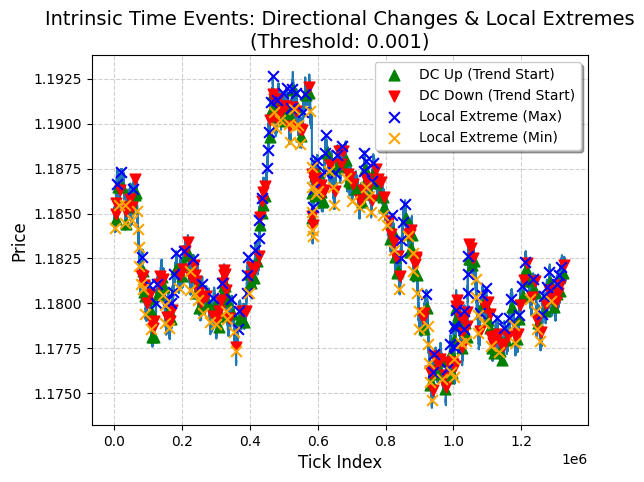

         Index       Balance Outcome    Return                DateTime
0       6895.0  10010.548612       W  0.001055 2026-02-01 19:04:56.950
1      30880.0  10020.757775       W  0.001020 2026-02-02 00:29:16.490
2      46833.0  10030.904008       W  0.001013 2026-02-02 03:16:04.341
3      50928.0  10041.056317       W  0.001012 2026-02-02 03:58:58.856
4      56926.0  10051.136508       W  0.001004 2026-02-02 05:02:21.248
..         ...           ...     ...       ...                     ...
136  1289356.0  10108.552984       W  0.001007 2026-02-27 04:55:51.874
137  1300378.0  10098.361443       L -0.001008 2026-02-27 08:42:06.228
138  1305513.0  10108.630267       W  0.001017 2026-02-27 09:37:12.633
139  1312547.0  10098.440547       L -0.001008 2026-02-27 10:38:42.503
140  1316440.0  10088.176948       L -0.001016 2026-02-27 11:15:17.737

[141 rows x 5 columns]


In [6]:
directional_change_threshold = 0.001
strategy_threshold = 0.001

mid_prices = tick_data["Mid Price"].to_numpy()
dc_events = calculate_intrinsic_events(mid_prices, threshold = directional_change_threshold)

print(dc_events.info())

plt.plot(range(mid_prices.shape[0]), mid_prices)

categories = [
        ('DC', 'U', 'green', '^', 'DC Up (Trend Start)'),
        ('DC', 'D', 'red', 'v', 'DC Down (Trend Start)'),
        ('LE', 'U', 'blue', 'x', 'Local Extreme (Max)'),
        ('LE', 'D', 'orange', 'x', 'Local Extreme (Min)')]

# 3. Plot each category as a scatter layer
for e_type, e_dir, color, marker, label in categories:
    mask = (dc_events['type'] == e_type) & (dc_events['dir'] == e_dir)
    subset = dc_events[mask]
    plt.scatter(subset['index'], subset['price'], 
                color=color, marker=marker, label=label, 
                s=60, zorder=5)

plt.title(f"Intrinsic Time Events: Directional Changes & Local Extremes\n(Threshold: {directional_change_threshold})", fontsize=14)
plt.xlabel("Tick Index", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

result = execute_strategy(tick_data, directional_change_threshold, strategy_threshold)
print(result)

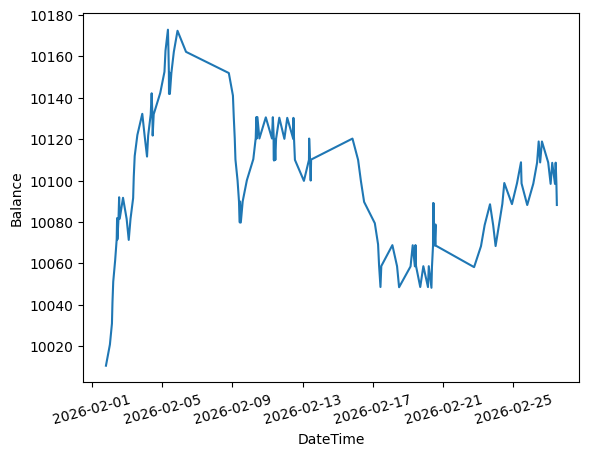

In [7]:
plt.plot(result["DateTime"], result["Balance"])

plt.xlabel("DateTime")
plt.xticks(rotation = 15)

plt.ylabel("Balance")

plt.ticklabel_format(axis = "y", style = "plain", useOffset = False)

plt.show()

<h1>Part 2 - Backtesting</h1>

The strategy will be backtested on 12 months of EUR/USD tick data from previously created parquet files, ranging from January 2025 to December 2025 inclusive. A range of directional change thresholds and strategy exit thresholds will be sweeped at regular intervals to produce comprehensive statistics on how the strategy performs on these datasets with different parameters. 

<h1>Step 1 - Load in the data</h1>

Parquet files are much quicker to read and they preserve the column data types of dataframes, and the function `get_tick_data()` already produced these files once a csv equivalent is read.

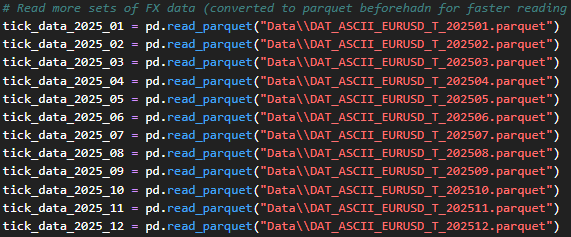

<h1>Step 2 - Backtest across a parameter sweep</h1>

Two ranges of values for the thresholds have been chosen: 10 values between 0.001 and 0.01 spaced with intervals of 0.001. Acros 12 months, this makes 1200 runs of the strategy, providing plenty of insight into it's performance across different market conditions. The metrics computed in this backtet are:

1. Number of Trades
2. Return %
3. Relative Maximum Drawdown
4. Sharpe Ratio (there is no risk-free return comparison to make here, so the risk-free rate is assumed to be zero)
5. Win Rate %
6. Maximum Consecutive Wins
7. Average Consecutive Wins
8. Maximum Consecutive Losses
9. Average Consevutive Losses

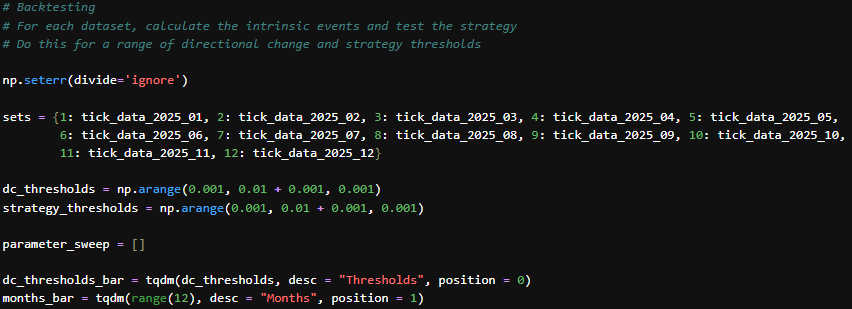

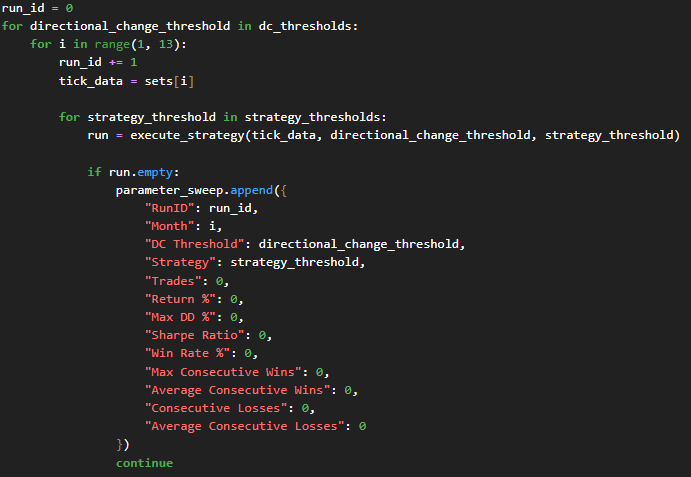

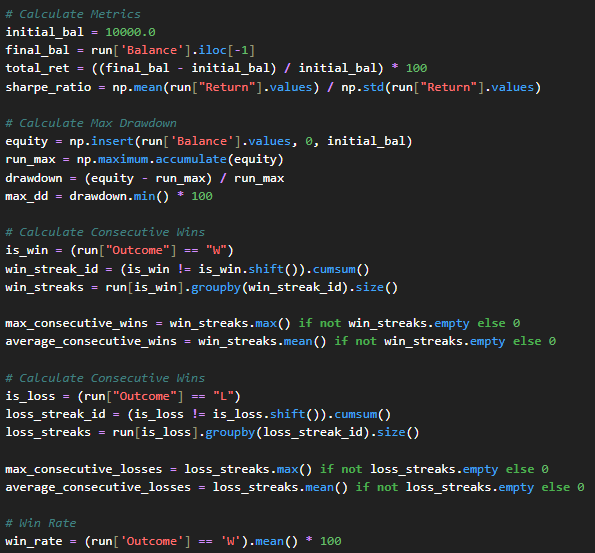

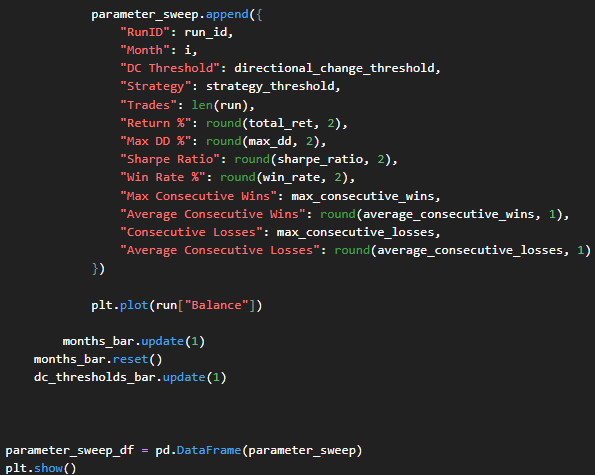

<h1>Step 5 - Visualise Results</h1>
Every time a run is performed, the balance across the run is plotted. normalising the x axis gives us the following plot of the balances

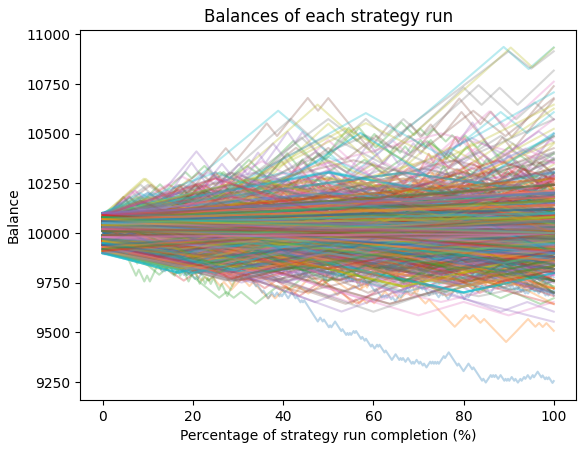

This graph is quite messy, but it indicates that on average the strategy architecture breaks even, tending to make money more often than losing it. Further analysis of the strategy's performance grouped by the directional change and strategy exit thresholds will reveal more about when the strategy is profitable.

<h1>Step 6 - Group Results by Parameters</h1>
Grouping the results dataframe by parameter allows us to properly analyse the performance of the strategy over the parameter pairs

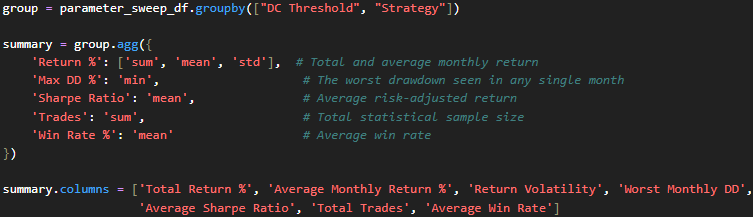

<h1>Step 7 - Detailed Analysis</h1>

We can plot a heatmap of the average and total (since there's 12 months of data, the total returns are essentially the yearly return of the strategy for that parameter combination). This heatmap tells us that the strategy performs better when pairing a coarser strategy exit threshold with a finer directional change parameter, although the strategy exit threshold is the bigger contributor to profitability. This is most likely because a tighter directional change threshold means that there's more room for price action when a strategy is opened, and the looser take-profits mean that the strategy wins more money per correct prediction.

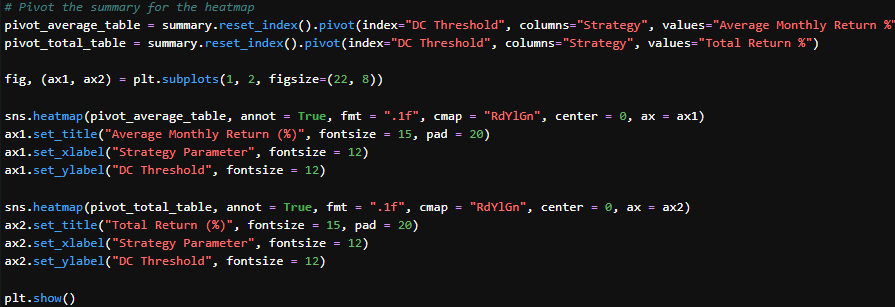

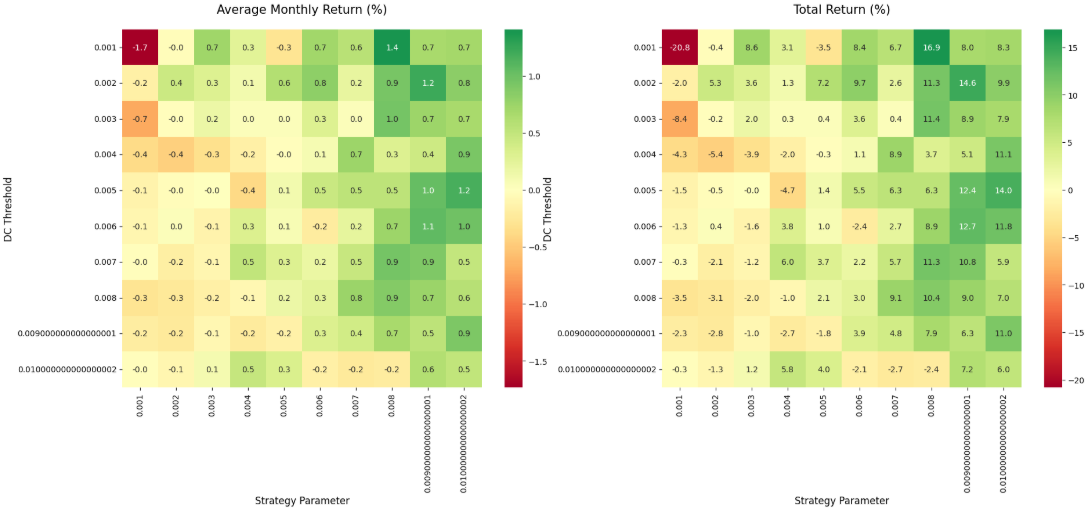

We can also plot a correlation matrix to see which parameters have the strongest effects on backtest statistics.

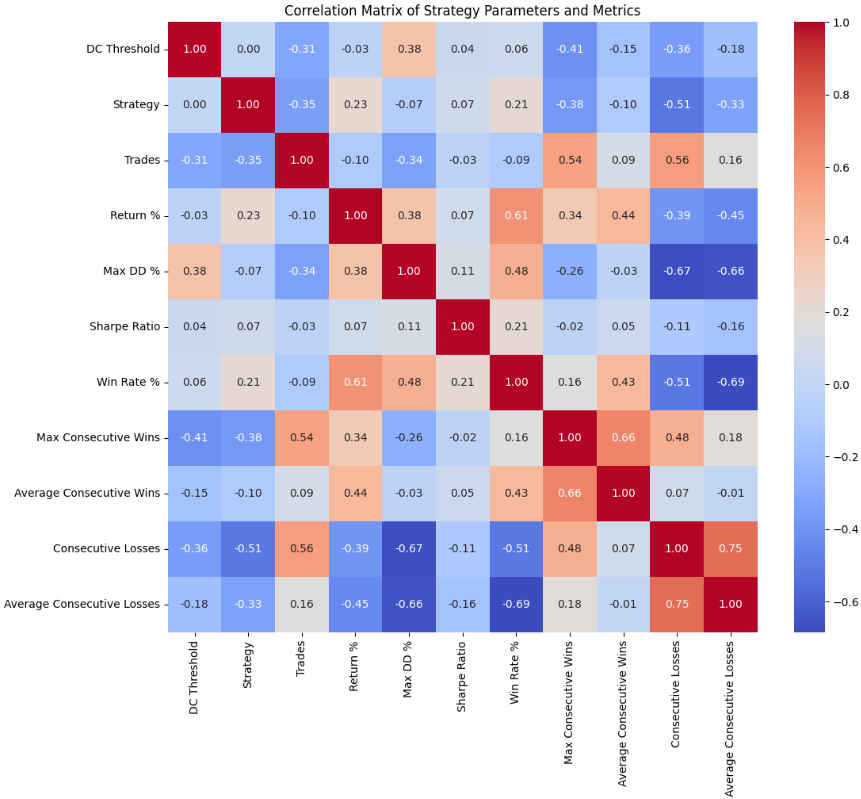


<h1>Results Discussion</h1>

The evidence in the results suggest that the strategy is sensitive to parameter choice and can hence be improved/optimised throughout time, with roughly 10 parameter combinations exceeding 10% annual returns. However this most likely is not a consistently profitable strategy architecture because of the weak mean return rate (0.27%) and average win rate (54%), and since trading fees have not been simulated here the returns would most definitely be lower in a real world live trading situation. To unlock the full potential of the strategy, more data would have to be passed in to test and train with, since purely tick level best bids and asks do not portray enough information to get an understanding of the market structure. It would also be difficult to determine the best performing parameter combinations ahead of time, there is no guarantee that the best working combination this year would work next year. There is also no guarantee that a working parameter combination would work on another currency pair, since they all exhibit different behaviours which will change and evolve. 

Across the 1200 backtests, the majority of them win and exhibit positive returns. The correlation matrix does not indicate that there is any correlation between the directional change threshold and returns & winrate, which is corroborated by the heatmaps. The matrix does indicate that there is a slight positive correlation between the strategy exit threshold and the returns & winrate, which reinforces the earlier observation of the strategy exit parameter being the deciding factor in the returns. There is also an inverse relationship between the number of trades and the returns & winrate, which implies that the strategy tends to perform better when less trades are made.

Based on these results, the following improvements can be made. If we assume that there is no instance in which a directional change threshold below 0.5 can result in the same profitability of values above 0.5 then the search space can be cut in half, allowing us to further select thresholds for fine tuning. We can also explore the possibility of opening multiple positions, allowing us to hedge against failing trades. If we implement more thresholds for each specific case (e.g. different thresholds for upwards and downwards DCs, different TP and SL thresholds) we can further improove the strategy and refine thresholds to be robust in different market conditions. Since we have bid and ask values, the spread can be tracked throughout the ticks to produce a new data input for the strategy. Predictive power can be improved by giving the strategy the means to learn, whether it's through genetic algorithms, reinformenet learning or other techniques.

Overall, the evidence suggests that this strategy architecture has the potential to be transformed into a robust trading strategy with parameter fine tuning and other optimisations, however as it is right now it lacks consistent profitability on a level that would justify using it.